# Data Dictionary Generator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/data-dict-gen/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/data-dict-gen/demo.ipynb)

> Point it at a table, get a documented data dictionary - types, PII flags, descriptions.

"What does `mrr_usd` mean? Is `full_name` PII? Why is `email` 20% null?" Every data team
loses hours to undocumented columns. This tool profiles a table and generates a data
dictionary automatically - semantic types, null rates, PII flags, plain-English
descriptions - so the answers live next to the data.

**What this notebook covers**
1. Profiling a column: type, nulls, cardinality, samples
2. Semantic typing from column names + values (id, email, currency, ...)
3. PII detection
4. A plain-English description per column - no LLM required
5. A chart of null rates + PII across the table
6. The Claude upgrade for richer business descriptions


## Step 1 - Semantic typing

`dtype` tells you `object` or `int64`; it doesn't tell you a column is an **email** or a
**currency**. We infer a *semantic* type by combining column-name hints with a look at the
actual values.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field

import pandas as pd


_NAME_HINTS = [
    (re.compile(r"(^id$|_id$|^id_|uuid|guid)", re.I), "id"),
    (re.compile(r"email|e_mail", re.I), "email"),
    (re.compile(r"phone|mobile|tel", re.I), "phone"),
    (re.compile(r"date|_at$|_on$|timestamp|created|updated|dob|birth", re.I), "date"),
    (re.compile(r"price|amount|cost|revenue|salary|balance|fee|usd|total", re.I), "currency"),
    (re.compile(r"(^is_|^has_|_flag$|active|enabled)", re.I), "boolean"),
    (re.compile(r"name|first|last|address|ssn|zip|postal", re.I), "pii_text"),
]
_EMAIL_RE = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")
_PII_SEMANTIC = {"email", "phone", "pii_text"}


def infer_semantic_type(name, series):
    for pat, label in _NAME_HINTS:
        if pat.search(name):
            return label
    non_null = series.dropna()
    if non_null.empty:
        return "text"
    sample = non_null.astype(str).head(50)
    if sample.map(lambda v: bool(_EMAIL_RE.match(v))).mean() > 0.8:
        return "email"
    if pd.api.types.is_bool_dtype(series) or set(non_null.unique()) <= {0, 1, True, False}:
        return "boolean"
    if pd.api.types.is_numeric_dtype(series):
        return "numeric"
    if non_null.nunique() <= max(20, int(0.1 * len(non_null))):
        return "category"
    return "text"


print("Semantic typer ready.")


Semantic typer ready.


## Step 2 - Profile every column

For each column we capture the profile signals a good data dictionary needs: dtype,
semantic type, null %, distinct count, a few sample values, and a PII flag.

In [2]:
@dataclass
class ColumnDoc:
    name: str
    dtype: str
    semantic_type: str
    null_pct: float
    unique_count: int
    sample_values: list = field(default_factory=list)
    is_pii: bool = False
    description: str = ""


def describe(col):
    base = {
        "id": f"Unique identifier ({col.unique_count} distinct values).",
        "email": "Email address of the record.",
        "phone": "Phone number contact field.",
        "date": "Date/time value.",
        "currency": "Monetary amount.",
        "boolean": "True/false flag.",
        "category": f"Categorical field with {col.unique_count} distinct categories.",
        "numeric": "Numeric measure.",
        "pii_text": "Free-text field containing personal information.",
        "text": "Free-text field.",
    }.get(col.semantic_type, "Field.")
    if col.null_pct > 0:
        base += f" {col.null_pct:.0f}% missing."
    if col.sample_values:
        base += " e.g. " + ", ".join(str(v) for v in col.sample_values[:3]) + "."
    return base


def build_dictionary(df):
    docs = []
    for name in df.columns:
        s = df[name]
        sem = infer_semantic_type(name, s)
        col = ColumnDoc(
            name=name, dtype=str(s.dtype), semantic_type=sem,
            null_pct=round(100.0 * s.isna().sum() / len(s), 1),
            unique_count=int(s.nunique()),
            sample_values=list(s.dropna().unique()[:5]),
            is_pii=sem in _PII_SEMANTIC,
        )
        col.description = describe(col)
        docs.append(col)
    return docs


df = pd.DataFrame({
    "customer_id": [1001, 1002, 1003, 1004, 1005],
    "email": ["a@x.com", "b@y.com", None, "d@z.com", "e@w.com"],
    "signup_date": ["2026-01-05", "2026-02-11", "2026-02-28", "2026-03-15", "2026-04-01"],
    "plan": ["pro", "free", "pro", "team", "free"],
    "mrr_usd": [29.0, 0.0, 29.0, 59.0, 0.0],
    "is_active": [True, False, True, True, False],
    "full_name": ["Ada Lovelace", "Alan Turing", "Grace Hopper", "Ken Thompson", "Katherine Johnson"],
})

docs = build_dictionary(df)
for c in docs:
    flag = " [PII]" if c.is_pii else ""
    print(f"{c.name:<14}{c.semantic_type:<10}{flag}")
    print("   ", c.description)


customer_id   id        
    Unique identifier (5 distinct values). e.g. 1001, 1002, 1003.
email         email      [PII]
    Email address of the record. 20% missing. e.g. a@x.com, b@y.com, d@z.com.
signup_date   date      
    Date/time value. e.g. 2026-01-05, 2026-02-11, 2026-02-28.
plan          category  
    Categorical field with 3 distinct categories. e.g. pro, free, team.
mrr_usd       currency  
    Monetary amount. e.g. 29.0, 0.0, 59.0.
is_active     boolean   
    True/false flag. e.g. True, False.
full_name     pii_text   [PII]
    Free-text field containing personal information. e.g. Ada Lovelace, Alan Turing, Grace Hopper.


## Step 3 - The dictionary as a table

Collapse the profiles into the artifact you actually hand off - one row per column, ready
to paste into a catalog, a dbt `schema.yml`, or a wiki.

In [3]:
dict_df = pd.DataFrame([{
    "column": c.name, "dtype": c.dtype, "semantic": c.semantic_type,
    "null_%": c.null_pct, "unique": c.unique_count,
    "PII": "yes" if c.is_pii else "", "description": c.description[:55] + "...",
} for c in docs])
dict_df


,column,dtype,semantic,null_%,unique,PII,description
0,customer_id,int64,id,0.0,5,,Unique identifier (5 distinct values). e.g. 10...
1,email,object,email,20.0,4,yes,Email address of the record. 20% missing. e.g....
2,signup_date,object,date,0.0,5,,"Date/time value. e.g. 2026-01-05, 2026-02-11, ..."
3,plan,object,category,0.0,3,,Categorical field with 3 distinct categories. ...
4,mrr_usd,float64,currency,0.0,3,,"Monetary amount. e.g. 29.0, 0.0, 59.0...."
5,is_active,bool,boolean,0.0,2,,"True/false flag. e.g. True, False...."
6,full_name,object,pii_text,0.0,5,yes,Free-text field containing personal informatio...


## Step 4 - Visualize data health

Two things a data steward scans first: **which columns leak PII** and **which are full of
nulls**. Put both on one chart.

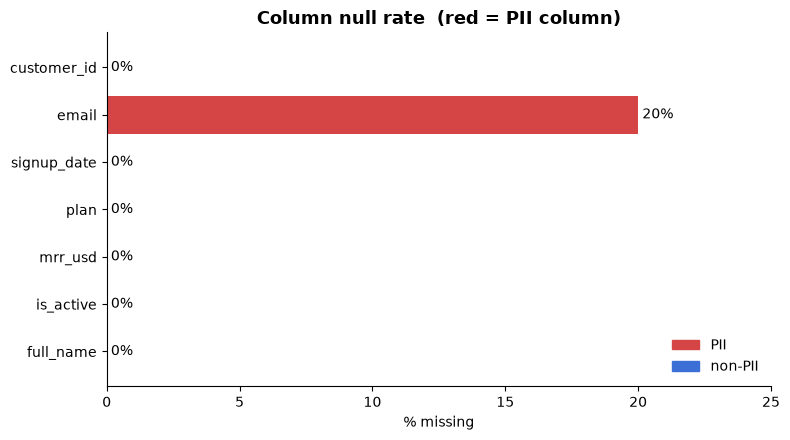

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

names = [c.name for c in docs]
nulls = [c.null_pct for c in docs]
colors = ["#d64545" if c.is_pii else "#3b6fd6" for c in docs]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(names[::-1], nulls[::-1], color=colors[::-1])
ax.set_title("Column null rate  (red = PII column)", fontsize=13, weight="bold")
ax.set_xlabel("% missing")
ax.set_xlim(0, max(max(nulls) + 5, 25))
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[Patch(color="#d64545", label="PII"), Patch(color="#3b6fd6", label="non-PII")],
          loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig("data_health.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Column | Semantic | PII | Note |
|--------|----------|-----|------|
| customer_id | id | - | primary key |
| email | email | **yes** | 20% missing |
| signup_date | date | - | |
| plan | category | - | 3 categories |
| mrr_usd | currency | - | revenue measure |
| is_active | boolean | - | |
| full_name | pii_text | **yes** | personal data |

Two PII columns flagged automatically, one data-quality issue surfaced (email nulls), and
every column now has a description - generated in one pass, zero manual typing.

In [5]:
# --- Upgrade to Claude (optional) ---
# import os, json, anthropic
#
# def llm_descriptions(docs, api_key, table="table"):
#     compact = [{"name": c.name, "semantic_type": c.semantic_type,
#                 "null_pct": c.null_pct, "samples": [str(v) for v in c.sample_values[:3]]}
#                for c in docs]
#     client = anthropic.Anthropic(api_key=api_key)
#     resp = client.messages.create(model="claude-sonnet-4-5", max_tokens=1500,
#         messages=[{"role": "user", "content":
#             f"Write business descriptions for columns in '{table}', from the profile only. "
#             "JSON: {\"descriptions\": {name: desc}}\n" + json.dumps(compact)}])
#     descs = json.loads(resp.content[0].text)["descriptions"]
#     for c in docs:
#         c.description = descs.get(c.name, c.description)
#     return docs
#
# # Claude turns "Monetary amount" into "Monthly recurring revenue per customer in USD."


In [6]:
# --- Try your own table ---
# import pandas as pd
# my_df = pd.read_csv("your_data.csv")
# for c in build_dictionary(my_df):
#     print(c.name, "->", c.description)


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 38 of the 60-day FDE portfolio.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version takes a CSV upload, shows the dictionary as a table, flags PII, and
exports to Markdown or CSV. Add an `ANTHROPIC_API_KEY` for Claude-written descriptions.